# Tests on Lyapunov exponents, using the Lyapunov toolbox

Background: there seems to still be a bug in there, so this file is build to find bugs in the Lyapunov Exponent algorithm, specifically local_FTLE
At the same time, the other function MLE is rougher but produces a more reliable estimate. It could be used as benchmark.


In [1]:
from Lyapunov_toolbox import local_FTLE
import numpy as np
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import matplotlib.pyplot as plt

/Users/queirolo/Desktop/GIT_repository/TUM_nODE/Lyapunov_toolbox.py:119: UserWarning: only one iteration to test results
  warnings.warn("only one iteration to test results")
/Users/queirolo/.local/share/virtualenvs/TUM_nODE-bBJE3WN-/lib/python3.9/site-packages/scipy/integrate/_odepack_py.py:248: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


1  out of  25  after  0.005439043045043945
11  out of  25  after  0.025667905807495117
21  out of  25  after  0.07567691802978516
[[ 2.00000005  2.00000005  2.00000005  2.00000005  2.00000005]
 [ 2.00000005  2.00000007  2.00000007  2.00000007  2.00000005]
 [ 2.00000005  2.00000007  2.00000007  2.00000007  2.00000005]
 [ 2.00000005  2.00000007  2.00000007 -0.43626467  2.00000005]
 [ 2.00000005  2.00000005  2.00000005  2.00000005  2.00000005]]


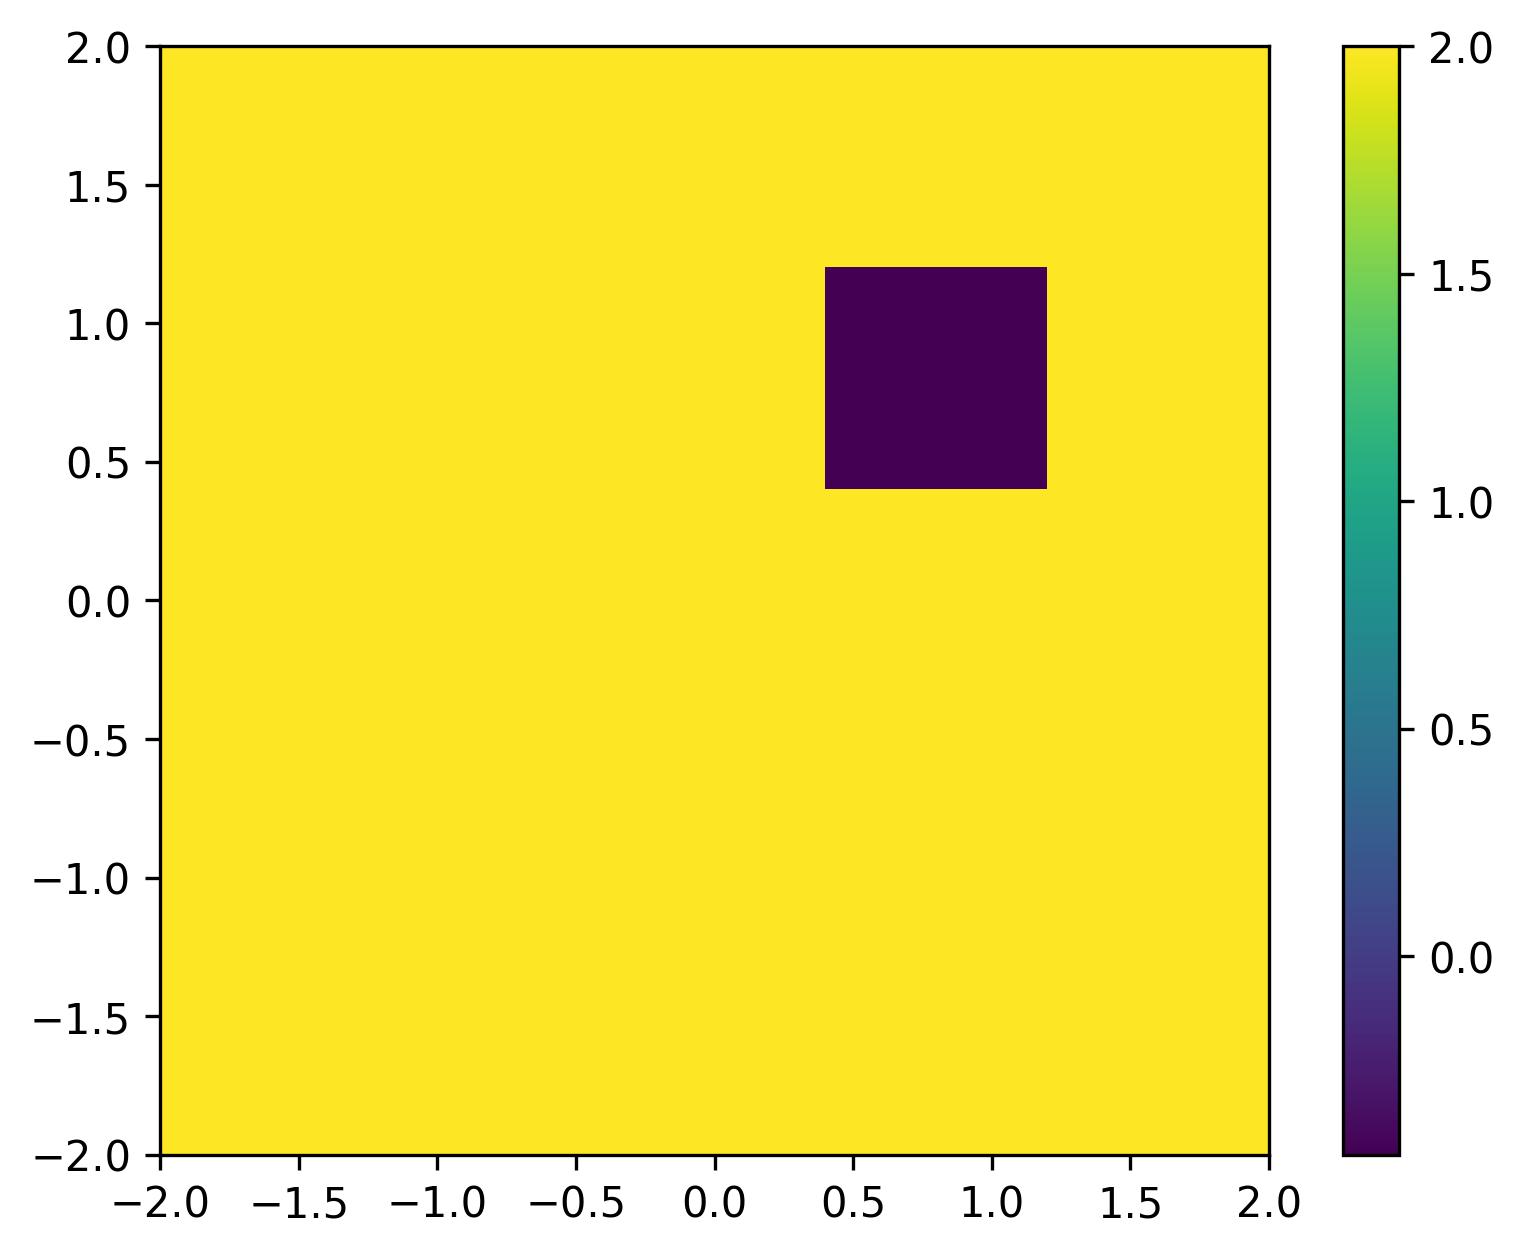

In [2]:
import time

# testing ODE with different MLE in phase space
def multiple_exponents_ODE2D():
    def func(x, t):
        if t<1/2 and np.linalg.norm(x-np.array([1,1]))<1/2:
            return -x
        else:
            return 2*x
    def der(x,t):
        if t<1/2 and np.linalg.norm(x-np.array([1,1]))<1/2:
            return -np.eye(2)
        else:
            return 2*np.eye(2)
    return func, der


func, der = multiple_exponents_ODE2D()

x_amount = 5
integration_time = 10
dt = 0.1

x = np.linspace(-2,2,x_amount)
y = np.linspace(-2,2,x_amount)
X, Y = np.meshgrid(x, y)
XY = np.array([X.flatten(), Y.flatten()])

lyap_small_exp = np.zeros(x_amount**2)
start_time = time.time()
for i in range(x_amount**2):
    lyap_small_exp[i] = np.max(local_FTLE(func, XY[:,i], 1, 0.1, der))
    iteration_time = time.time() - start_time
    if np.mod(i, 10) == 0:
        print(i+1,' out of ', x_amount**2, ' after ', iteration_time)
    # print(lyap[i])
    #break
lyap_small_exp = np.reshape(lyap_small_exp, (x_amount,x_amount))
print(lyap_small_exp)

# Create heatmap using imshow
from IPython.display import Image

file_name = 'MLE_analytic_2DExp.png'

anodeimg = plt.imshow(np.rot90(lyap_small_exp), origin='upper', extent=(-2, 2, -2, 2), cmap='viridis')
vmin, vmax = anodeimg.get_clim()
plt.colorbar()  # Show color scale
plt.savefig(file_name, bbox_inches='tight', dpi=300, format='png', facecolor = 'white')
plt.close()

img1 = Image(file_name, width = 400)
display(img1)

In [3]:
## the simplest example: 1D linear 

def linear1D():
    def func(x_func, t):
        #print(t)
        return x_func
    def derivative(x_func, t):
        return np.array([[1.0]])
    return func, derivative

In [4]:
## a little harder test case : the Lorentz system
def lorenz():
    sigma = 10
    beta = 8/3
    rho = 28
    def func(x_func, t):
        #print(t)
        x = x_func[0]
        y = x_func[1]
        z = x_func[2]
        lor = np.array([sigma*(y-x), x*(rho - z)-y, x*y - beta*z])
        return lor
    def derivative(x_func, t):
        x = x_func[0]
        y = x_func[1]
        z = x_func[2]
        return np.array([[-sigma, sigma, 0],[rho-z, -1, -x],[y, x, -beta]])
    return func, derivative

In [5]:
## a little harder test case: the Roessler attractor
def rossler():
    a = 0.1
    b = 0.1
    c = 14
    def func(x_func, t):
        #print(t)
        x = x_func[0]
        y = x_func[1]
        z = x_func[2]
        ross = np.array([-y-z, x+a*y, b+z*(x-c)])
        return ross
    def derivative(x_func, t):
        x = x_func[0]
        y = x_func[1]
        z = x_func[2]
        return np.array([[0, -1, -1],[1, a, 0],[z, 0, x-c]])
    return func, derivative

In [6]:
import numpy as np
import scipy

print('\nResults for 1D linear')
lin1D_func, lin1D_der = linear1D()
print('Refined implementation \n', local_FTLE(lin1D_func, np.array([1]), 60, 0.1, lin1D_der), 'VS 1\n\n') 

test = True
if test:
    lor_func, lor_der = lorenz()
    print('Results for Lorentz')
    print('Refined implementation \n', local_FTLE(lor_func, np.array([1,2,3]), 100, 0.1, lor_der), 'VS 0.90')
    
    print('\nResults for Rossler show convergence over time')
    ross_func, ross_der = rossler()
    print('Refined implementation t=100\n', local_FTLE(ross_func, np.array([1,2,3]), 100, 0.1, ross_der), 'VS 0.0714, 0, -5.3943')
    print('Refined implementation t=500\n', local_FTLE(ross_func, np.array([1,2,3]), 500, 0.1, ross_der), 'VS 0.0714, 0, -5.3943')
    print('Refined implementation t=1500\n', local_FTLE(ross_func, np.array([1,2,3]), 1500, 0.1, ross_der), 'VS 0.0714, 0, -5.3943')


Results for 1D linear
Refined implementation 
 [1.00000002] VS 1


Results for Lorentz
Refined implementation 
 [-0.00095566 -0.0201753  -0.33404596] VS 0.90

Results for Rossler show convergence over time
Refined implementation t=100
 [ 0.01048969  0.01018673 -0.38966869] VS 0.0714, 0, -5.3943
Refined implementation t=500
 [ 0.00209795  0.00203735 -0.07792821] VS 0.0714, 0, -5.3943
Refined implementation t=1500
 [ 0.00069931  0.00067912 -0.02598012] VS 0.0714, 0, -5.3943


In [7]:
import time

# testing ODE with different MLE in phase space
def weirdODE1D():
    def func(x, t):
        if x<0:
            return -x # contracting
        else:
            return x # expanding
    def der(x,t):
        if x<0:
            return np.array([[-1]]) # contracting
        else:
            return np.array([[1]]) # expanding
    return func, der


def weirdODE2D():
    def func(x, t):
        return np.abs(x) # expanding
    def der(x,t):
        return np.diagflat(np.sign(x)) # expanding
    return func, der



weird1D_func, weird1D_der = weirdODE1D()
local_FTLE(weird1D_func, np.array([1]), 60, 0.1, weird1D_der)

x_amount = 10
integration_time = 10
dt = 0.1

x = np.linspace(-2,2,x_amount)

lyap_weird = np.zeros(x_amount)
start_time = time.time()
for i in range(x_amount):
    lyap_weird[i] = np.max(local_FTLE(weird1D_func, np.array([x[i]]), 20, 0.1, weird1D_der))
    iteration_time = time.time() - start_time
    if np.mod(i, 10) == 0:
        print(i+1,' out of ', x_amount, ' after ', iteration_time)

print(lyap_weird)

1  out of  10  after  0.003452777862548828
[-0.99470871 -0.99843804 -0.99744023 -0.99759808 -0.99759808  1.00000002
  1.00000002  1.00000002  1.00000002  1.00000002]


# Tests involving the NeuralODE code

First, we need to set up the NeuralODE and test that we can access all that matters

56


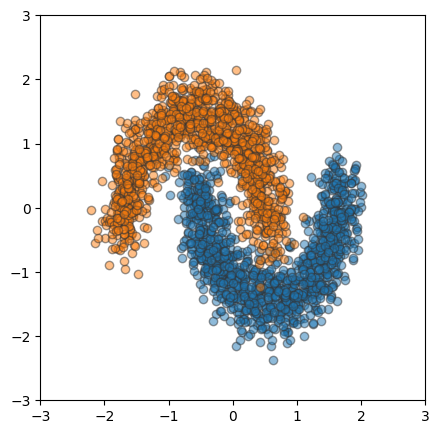

In [8]:
from models.neural_odes import NeuralODE
from models.training import visualize_dataloader
from minimal_neuralODE import build_neuralODE, plot_data
import torch
import numpy as np


nODE, dataloader = build_neuralODE(trained = False, data = True)


Then, we want to test that the derivative we are retrieving makes sense w.r.t. the right hand side

We check this by comparign with a numerical derivative taken with the standard finite difference method

In [12]:
def finite_differences(f, t, x, eps = 0.1):
    x_temp = torch.clone(x)
    der = torch.empty(f(t,x).shape[0], x.shape[0])
    for i in range(len(x)):
        x_temp[i] = x[i] + eps
        der[:,i] = (f(t,x_temp) - f(t,x))/eps
        x_temp[i] = x[i]  # change back
    return der

In [13]:
finite_differences(nODE.flow.dynamics.forward, t, x) 

tensor([[ 0.4342,  0.0600],
        [-0.1964,  0.5852]], grad_fn=<CopySlices>)

0 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(4.4874e-06)
1 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(1.4732e-05)
2 tensor([[10.2999,  1.4000],
        [12.3001,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0002)
3 tensor([[10.2997,  1.4000],
        [12.3024,  9.1019]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0031)
4 tensor([[10.2806,  1.3924],
        [12.3215,  9.0790]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0366)
5 tensor([[10.2997,  1.3351],
        [12.5885,  9.1553]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.3008)
6 tensor([[ 9.5367,  1.9073],
        [15.2588,  7.6294]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(3.4289)


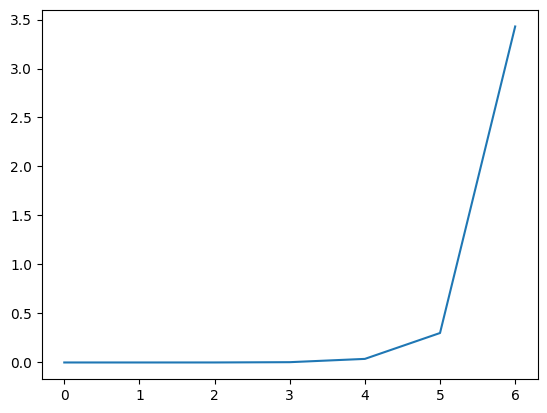

In [14]:
x = torch.Tensor([2.3, 1.4])
y = torch.Tensor([[2.3, 1.4],[12.3, 1.1]])
x_mat = torch.diag_embed(x)

silly_function = lambda t, x : x*8 + y.matmul(x)
derivative = lambda t, x : 8*torch.eye(2) + y

error = torch.empty(7)
for i in range(7):
    print(i,finite_differences(silly_function, t, x, eps=10**-i), '\n', derivative(t, x))
    error[i] = torch.norm(finite_differences(silly_function, t, x, eps=10**-i) - derivative(t, x))
    print(error[i])
plt.plot(error)


In [18]:
x = torch.Tensor([2.5889,0.245678])

finite_diff = finite_differences(nODE.flow.dynamics.forward, t, x, eps=10**-3).detach()
print('finite diff\n', finite_diff)

# other option: autograd
x_torch = x
x_torch.requires_grad=True
f_x_t = lambda x: nODE.flow.dynamics.forward(t, x)
autograd = torch.autograd.functional.jacobian(f_x_t, x_torch) # symbolical (I think)
print('autograd\n', autograd)

analytical = nODE.flow.dynamics.derivative(t, x)
print('analytical\n', analytical)

print('error autograd VS finite diff', torch.norm(autograd - finite_diff))
print('error autograd VS analytic', torch.norm(autograd - analytical))

finite diff
 tensor([[ 0.0904,  0.0121],
        [-0.2064,  0.6279]])
autograd
 tensor([[ 0.0905,  0.0121],
        [-0.2064,  0.6279]])
analytical
 tensor([[ 0.0905,  0.0121],
        [-0.2064,  0.6279]])
error autograd VS finite diff tensor(0.0001)
error autograd VS analytic tensor(0.)


In [16]:
nODE.flow.dynamics.fc2_time[0].weight

Parameter containing:
tensor([[ 0.6408,  0.0858],
        [-0.2071,  0.6300]], requires_grad=True)

In [17]:
nODE.architecture

'outside'

In [18]:
tensor1 = torch.randn(4, 4)
tensor2 = torch.randn(4)
a=torch.matmul(tensor2, tensor1)
a2=torch.matmul(tensor1, tensor2)
print(a, '\n', a2)

tensor([1.7837, 0.0979, 0.4346, 0.2488]) 
 tensor([ 0.4958,  0.6833, -0.5847, -0.7467])


Now the actual FTLE test starts

In [19]:
x_amount = 10 
T = 4 
integration_time = 20
dt = 0.1
plotlim = [-3, 3]
boundary = np.abs(plotlim[0])

x = np.linspace(-boundary,boundary,x_amount) 
y = np.linspace(-boundary,boundary,x_amount) 
X, Y = np.meshgrid(x, y) 
XY = np.array([X.flatten(), Y.flatten()])

lyap = np.zeros(x_amount**2) 
start_time = time.time() 
for i in range(x_amount**2): 
    lyap[i] = np.max(local_FTLE(nODE, XY[:,i], integration_time, 0.1)) 
    iteration_time = time.time() - start_time 
    if np.mod(i, 10) == 0: 
        print(i+1,' out of ', x_amount**2, ' after ', iteration_time) 
    # print(lyap[i]) 
    #break l
lyap2 = np.reshape(lyap, (x_amount,x_amount)) 

/Users/queirolo/Desktop/GIT_repository/TUM_nODE/Lyapunov_toolbox.py:119: UserWarning: only one iteration to test results
  warnings.warn("only one iteration to test results")
/Users/queirolo/Desktop/GIT_repository/TUM_nODE/models/neural_odes.py:120: UserWarning: Extending the dynamics
  warn('Extending the dynamics')


1  out of  100  after  0.22547292709350586
11  out of  100  after  2.349771022796631
21  out of  100  after  4.4061830043792725
31  out of  100  after  6.491305112838745
41  out of  100  after  8.47711181640625
51  out of  100  after  10.613584041595459
61  out of  100  after  12.76741886138916
71  out of  100  after  15.038901090621948
81  out of  100  after  17.20107412338257
91  out of  100  after  19.574312925338745


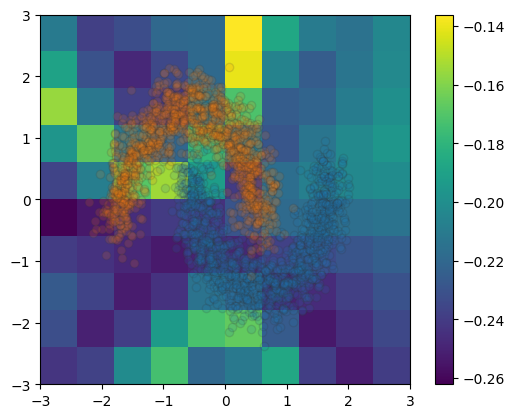

In [20]:
import matplotlib.pyplot as plt

plt.imshow(lyap2, origin='lower', extent=(-boundary, boundary, -boundary, boundary), cmap='viridis')
plt.colorbar()  # Show color scale

x, y = dataloader.dataset.tensors
plotlim = [-3, 3]    
data_0 = x[y[:,0] > 0]
data_1 = x[y[:,0] < 0]
plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333",  alpha = 0.15)
plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", alpha = 0.15)
plt.xlim(plotlim)
plt.ylim(plotlim)
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

#plt.savefig('Lyapunov_for_moons')
plt.show()

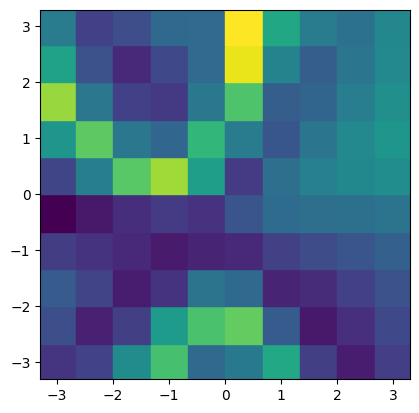

In [21]:
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')

In [22]:
nODE.architecture

'outside'

In [23]:
def easy_lyap(x_amount, integration_time, f = nODE, jac = None):
    dt = 0.1
    boundary = np.abs(plotlim[0])

    x = np.linspace(-boundary,boundary,x_amount) 
    y = np.linspace(-boundary,boundary,x_amount) 
    X, Y = np.meshgrid(x, y) 
    XY = np.array([X.flatten(), Y.flatten()])

    lyap = np.zeros(x_amount**2) 
    start_time = time.time() 
    for i in range(x_amount**2): 
        if jac is None:
            lyap[i] = np.max(local_FTLE(f, XY[:,i], integration_time, 0.1)) 
        else:
            lyap[i] = np.max(local_FTLE(f, XY[:,i], integration_time, 0.1, der = jac)) 
        iteration_time = time.time() - start_time 
    return lyap

In [24]:
# analytical derivatives

f = lambda x, t: nODE.flow.dynamics.forward(t,torch.Tensor(x)).detach()
jac = lambda x, t: nODE.flow.dynamics.derivative(t,torch.Tensor(x)).detach()

autograd and normal integration time


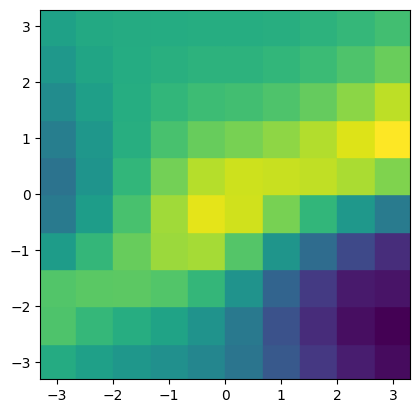

analytical derivatives, normal integration time


/Users/queirolo/Desktop/GIT_repository/TUM_nODE/models/neural_odes.py:164: UserWarning: Extending the dynamics
  warn('Extending the dynamics')


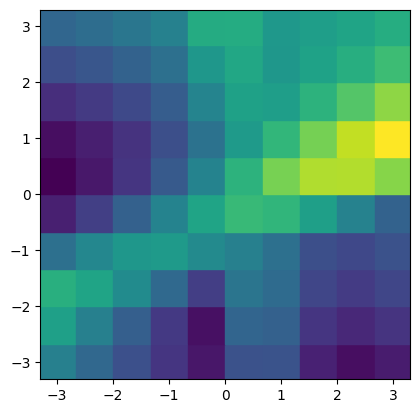

autograd, long integration


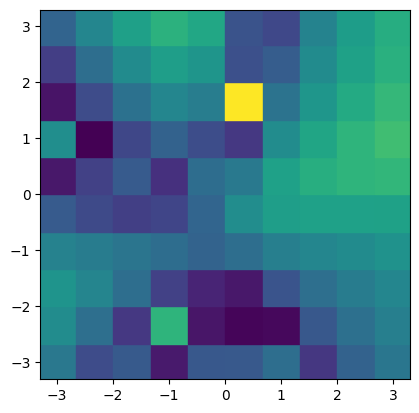

analytical, long integration time


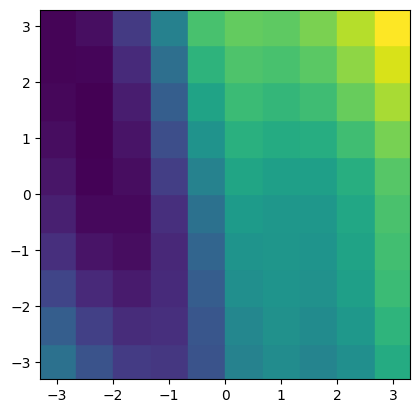

In [25]:
print('autograd and normal integration time')

lyap = easy_lyap(10, T)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('analytical derivatives, normal integration time')

lyap = easy_lyap(10, T, f = f, jac = jac)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('autograd, long integration')

lyap = easy_lyap(10, 10*T)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('analytical, long integration time')

lyap = easy_lyap(10, 10*T, f = f, jac = jac)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

In [26]:
T

4

In [27]:
def rowKronecker(x_vector, y_matrix):
    temp = [x_vector[i].detach() * y_matrix[i, :].detach() for i in range(len(x))]
    out = torch.Tensor()
    out = torch.cat(temp, out=out).reshape(y_matrix.shape)
    return out

w_t = torch.Tensor([[1,2],[3.,10]])
x = torch.Tensor([3,5])
b_t = 0*torch.Tensor([1.,1.])
non_linear_derivative = lambda input : 1 - torch.tanh(input) * torch.tanh(input)

y = (w_t.matmul(x) + b_t)
print(y)
f_y = non_linear_derivative(y)
print(f_y)
out = rowKronecker(non_linear_derivative(w_t.matmul(x) + b_t), w_t)
print(out)

tensor([13., 59.])
tensor([0., 0.])
tensor([[0., 0.],
        [0., 0.]])


In [18]:
out

tensor([[0., 0.],
        [0., 0.]])